In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

orders = pd.read_csv('blinkit_orders.csv')
order_items = pd.read_csv('blinkit_order_items.csv')
products = pd.read_csv('blinkit_products.csv')

print("Orders Shape:", orders.shape)
print("Order Items Shape:", order_items.shape)
print("Products Shape:", products.shape)

orders.head()

Orders Shape: (5000, 10)
Order Items Shape: (5000, 4)
Products Shape: (268, 10)


,order_id,customer_id,order_date,promised_delivery_time,actual_delivery_time,delivery_status,order_total,payment_method,delivery_partner_id,store_id
0,1961864118,30065862,2024-07-17 08:34:01,2024-07-17 08:52:01,2024-07-17 08:47:01,On Time,3197.07,Cash,63230,4771
1,1549769649,9573071,2024-05-28 13:14:29,2024-05-28 13:25:29,2024-05-28 13:27:29,On Time,976.55,Cash,14983,7534
2,9185164487,45477575,2024-09-23 13:07:12,2024-09-23 13:25:12,2024-09-23 13:29:12,On Time,839.05,UPI,39859,9886
3,9644738826,88067569,2023-11-24 16:16:56,2023-11-24 16:34:56,2023-11-24 16:33:56,On Time,440.23,Card,61497,7917
4,5427684290,83298567,2023-11-20 05:00:39,2023-11-20 05:17:39,2023-11-20 05:18:39,On Time,2526.68,Cash,84315,2741


In [2]:
print("\nOrders Missing Values")
print(orders.isnull().sum())

print("\nOrder Items Missing Values")
print(order_items.isnull().sum())

print("\nProducts Missing Values")
print(products.isnull().sum())



Orders Missing Values
order_id                  0
customer_id               0
order_date                0
promised_delivery_time    0
actual_delivery_time      0
delivery_status           0
order_total               0
payment_method            0
delivery_partner_id       0
store_id                  0
dtype: int64

Order Items Missing Values
order_id      0
product_id    0
quantity      0
unit_price    0
dtype: int64

Products Missing Values
product_id           0
product_name         0
category             0
brand                0
price                0
mrp                  0
margin_percentage    0
shelf_life_days      0
min_stock_level      0
max_stock_level      0
dtype: int64


In [3]:
df = order_items.merge(
    products,
    on='product_id',
    how='left'
)

df = df.merge(
    orders,
    on='order_id',
    how='left'
)

print(df.shape)
df.head()

(5000, 22)


,order_id,product_id,quantity,unit_price,product_name,category,brand,price,mrp,margin_percentage,...,max_stock_level,customer_id,order_date,promised_delivery_time,actual_delivery_time,delivery_status,order_total,payment_method,delivery_partner_id,store_id
0,1961864118,642612,3,517.03,Pet Treats,Pet Care,Pillay-Ahuja,517.03,795.43,35.0,...,57,30065862,2024-07-17 08:34:01,2024-07-17 08:52:01,2024-07-17 08:47:01,On Time,3197.07,Cash,63230,4771
1,1549769649,378676,1,881.42,Orange Juice,Cold Drinks & Juices,Baral-Kamdar,881.42,1259.17,30.0,...,65,9573071,2024-05-28 13:14:29,2024-05-28 13:25:29,2024-05-28 13:27:29,On Time,976.55,Cash,14983,7534
2,9185164487,741341,2,923.84,Eggs,Dairy & Breakfast,Prasad LLC,923.84,1154.80,20.0,...,62,45477575,2024-09-23 13:07:12,2024-09-23 13:25:12,2024-09-23 13:29:12,On Time,839.05,UPI,39859,9886
3,9644738826,561860,1,874.78,Orange Juice,Cold Drinks & Juices,Gupta Ltd,874.78,1249.69,30.0,...,90,88067569,2023-11-24 16:16:56,2023-11-24 16:34:56,2023-11-24 16:33:56,On Time,440.23,Card,61497,7917
4,5427684290,602241,2,976.55,Nuts,Snacks & Munchies,Bahl-Pau,976.55,1502.38,35.0,...,75,83298567,2023-11-20 05:00:39,2023-11-20 05:17:39,2023-11-20 05:18:39,On Time,2526.68,Cash,84315,2741


In [4]:
total_revenue = orders['order_total'].sum()
total_orders = orders['order_id'].nunique()

print("Total Revenue:", round(total_revenue,2))
print("Total Orders:", total_orders)

Total Revenue: 11009308.5
Total Orders: 5000


In [7]:
df['sales'] = df['quantity'] * df['unit_price']

category_sales = (
    df.groupby('category')['sales']
    .sum()
    .sort_values(ascending=False)
)

print(category_sales.head(10))

category
Dairy & Breakfast       639222.19
Pharmacy                592368.57
Fruits & Vegetables     559053.08
Pet Care                539888.75
Household Care          444244.25
Personal Care           394894.61
Snacks & Munchies       394648.71
Cold Drinks & Juices    392717.62
Grocery & Staples       359937.82
Baby Care               348227.18
Name: sales, dtype: float64


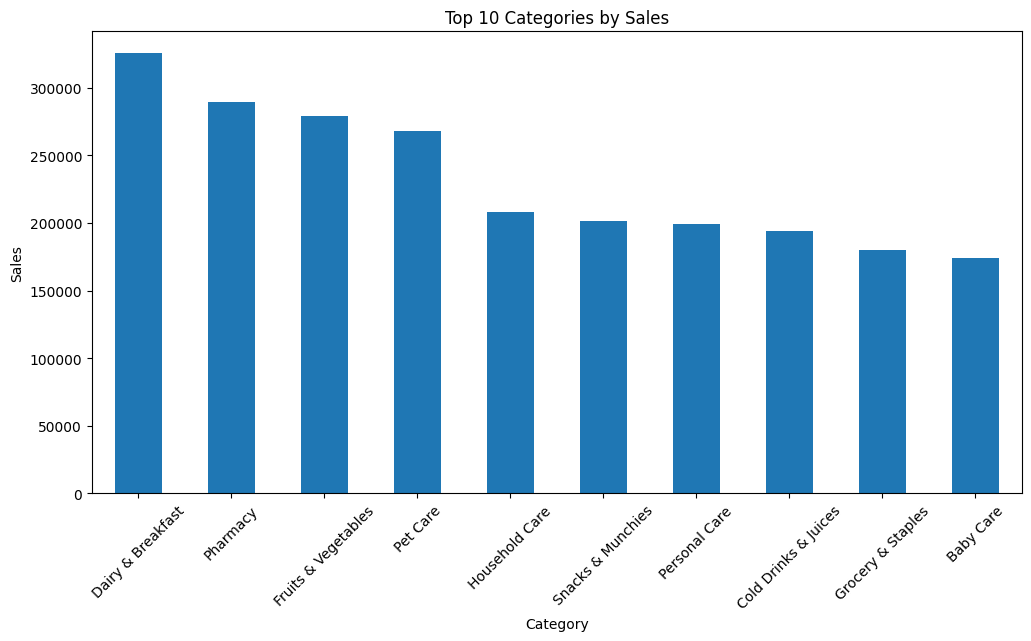

In [6]:
plt.figure(figsize=(12,6))

category_sales.head(10).plot(kind='bar')

plt.title("Top 10 Categories by Sales")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.xticks(rotation=45)

plt.show()

In [8]:
total_revenue = df['sales'].sum()

total_orders = orders['order_id'].nunique()

avg_order_value = (
    total_revenue / total_orders
)

total_products = products['product_id'].nunique()

print(f"Total Revenue: ₹{total_revenue:,.2f}")
print(f"Total Orders: {total_orders}")
print(f"Average Order Value: ₹{avg_order_value:,.2f}")
print(f"Total Products: {total_products}")

Total Revenue: ₹4,972,415.43
Total Orders: 5000
Average Order Value: ₹994.48
Total Products: 268


In [9]:
top_products = (
    df.groupby('product_name')['sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)

product_name
Vitamins          260822.01
Pet Treats        252007.37
Cough Syrup       203569.98
Toilet Cleaner    199837.48
Bread             184851.10
Dish Soap         184441.21
Cat Food          166596.39
Baby Wipes        158768.41
Onions            138858.42
Baby Food         137442.79
Name: sales, dtype: float64


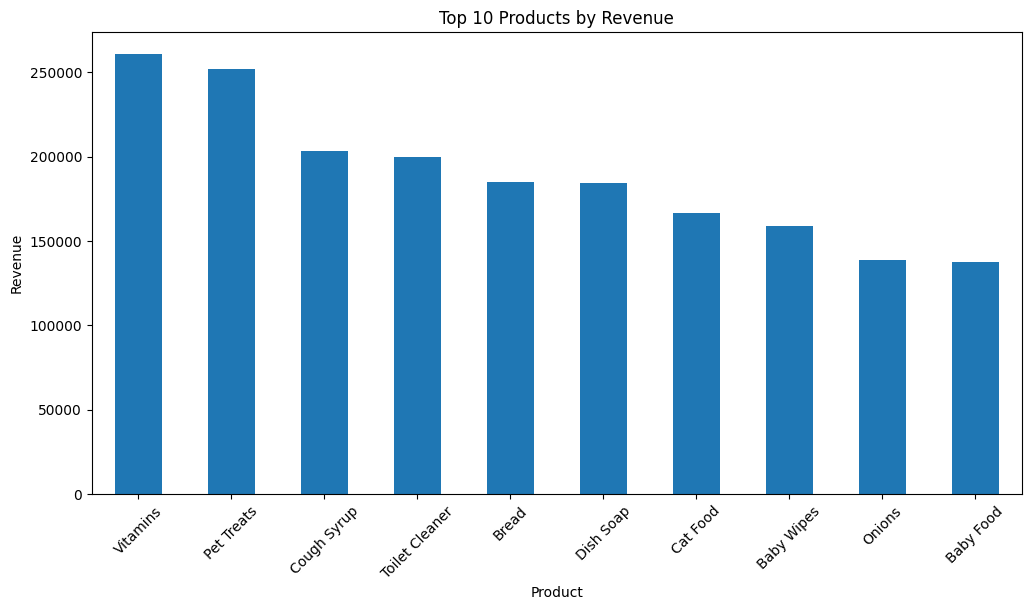

In [10]:
plt.figure(figsize=(12,6))

top_products.plot(kind='bar')

plt.title('Top 10 Products by Revenue')
plt.ylabel('Revenue')
plt.xlabel('Product')

plt.xticks(rotation=45)

plt.show()

In [11]:
delivery_status = (
    orders['delivery_status']
    .value_counts()
)

print(delivery_status)

delivery_status
On Time                  3470
Slightly Delayed         1037
Significantly Delayed     493
Name: count, dtype: int64


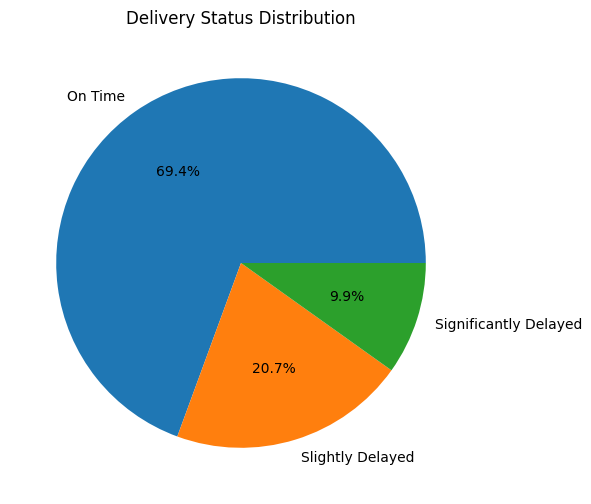

In [12]:
plt.figure(figsize=(6,6))

delivery_status.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel('')

plt.title(
    'Delivery Status Distribution'
)

plt.show()

In [13]:
customers = pd.read_csv('blinkit_customers.csv')

print(customers.shape)

customers.head()

(2500, 11)


,customer_id,customer_name,email,phone,address,area,pincode,registration_date,customer_segment,total_orders,avg_order_value
0,97475543,Niharika Nagi,ektataneja@example.org,912987579691,"23, Nayar Path, Bihar Sharif-154625",Udupi,321865,2023-05-13,Premium,13,451.92
1,22077605,Megha Sachar,vedant45@example.com,915123179717,"51/302, Buch Chowk\nSrinagar-570271",Aligarh,149394,2024-06-18,Inactive,4,825.48
2,47822591,Hema Bahri,samiazaan@example.com,910034076149,"941\nAnne Street, Darbhanga 186125",Begusarai,621411,2024-09-25,Regular,17,1969.81
3,79726146,Zaitra Vig,ishanvi87@example.org,916264232390,"43/94, Ghosh, Alappuzha 635655",Kozhikode,826054,2023-10-04,New,4,220.09
4,57102800,Januja Verma,atideshpande@example.org,917293526596,"06\nOm, Ambarnath 477463",Ichalkaranji,730539,2024-03-22,Inactive,14,578.14


In [14]:
customers['customer_segment'].value_counts()

,count
customer_segment,
Regular,639
Premium,633
New,628
Inactive,600


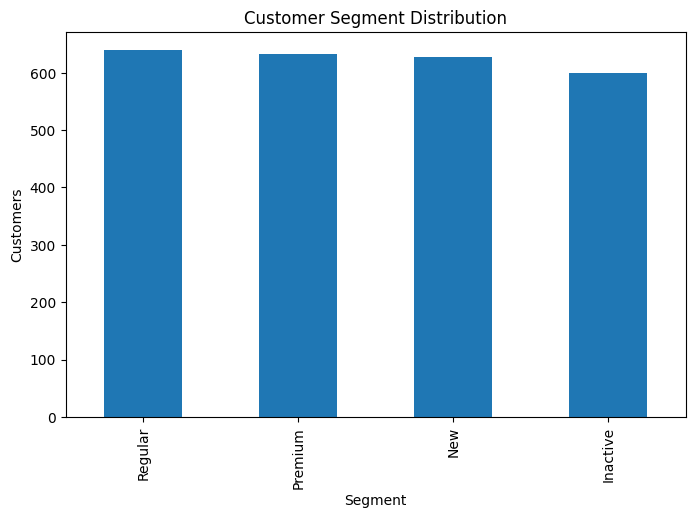

In [15]:
segment_counts = customers['customer_segment'].value_counts()

plt.figure(figsize=(8,5))
segment_counts.plot(kind='bar')

plt.title('Customer Segment Distribution')
plt.xlabel('Segment')
plt.ylabel('Customers')

plt.show()

In [16]:
segment_aov = customers.groupby(
    'customer_segment'
)['avg_order_value'].mean()

print(segment_aov)

customer_segment
Inactive    1102.150000
New         1116.635557
Premium     1101.473965
Regular     1089.467042
Name: avg_order_value, dtype: float64


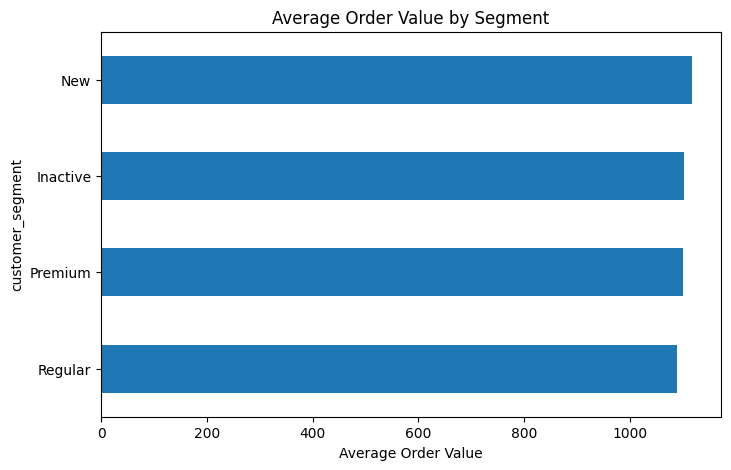

In [17]:
plt.figure(figsize=(8,5))

segment_aov.sort_values().plot(
    kind='barh'
)

plt.title(
    'Average Order Value by Segment'
)

plt.xlabel('Average Order Value')

plt.show()

In [18]:
top_customers = customers.sort_values(
    'total_orders',
    ascending=False
)

top_customers[
    ['customer_name',
     'customer_segment',
     'total_orders']
].head(10)

,customer_name,customer_segment,total_orders
2413,Thomas Walia,Regular,20
2408,Udarsh Rao,Regular,20
2036,Ojas Gour,Premium,20
1765,Mitesh Sehgal,New,20
318,Ayush Tripathi,New,20
1791,Chaman Merchant,Premium,20
2488,Garima Behl,New,20
445,Ayaan Tiwari,Inactive,20
2001,Pratyush Dhar,Inactive,20
76,Jonathan Virk,New,20


In [19]:
customers['customer_value'] = (
    customers['total_orders']
    * customers['avg_order_value']
)

top_value_customers = customers.sort_values(
    'customer_value',
    ascending=False
)

top_value_customers[
    ['customer_name',
     'customer_segment',
     'customer_value']
].head(10)

,customer_name,customer_segment,customer_value
2488,Garima Behl,New,39634.4
2001,Pratyush Dhar,Inactive,39389.0
385,Bakhshi Varkey,Premium,39373.0
205,Pratyush De,Regular,38716.8
980,Ronith Sami,New,38472.8
1989,Yashawini Barman,Premium,38467.8
673,Bimala Sura,New,38454.2
2346,Dakshesh Varughese,Regular,38283.6
1870,Quincy Kari,Inactive,37925.4
1349,Girish Sem,Inactive,37876.6


In [20]:
orders['promised_delivery_time'] = pd.to_datetime(
    orders['promised_delivery_time']
)

orders['actual_delivery_time'] = pd.to_datetime(
    orders['actual_delivery_time']
)

orders['delay_minutes'] = (
    orders['actual_delivery_time']
    - orders['promised_delivery_time']
).dt.total_seconds() / 60

orders[['delay_minutes']].head()

,delay_minutes
0,-5.0
1,2.0
2,4.0
3,-1.0
4,1.0


In [21]:
print(
    "Average Delay:",
    round(
        orders['delay_minutes'].mean(),
        2
    ),
    "minutes"
)

Average Delay: 4.44 minutes


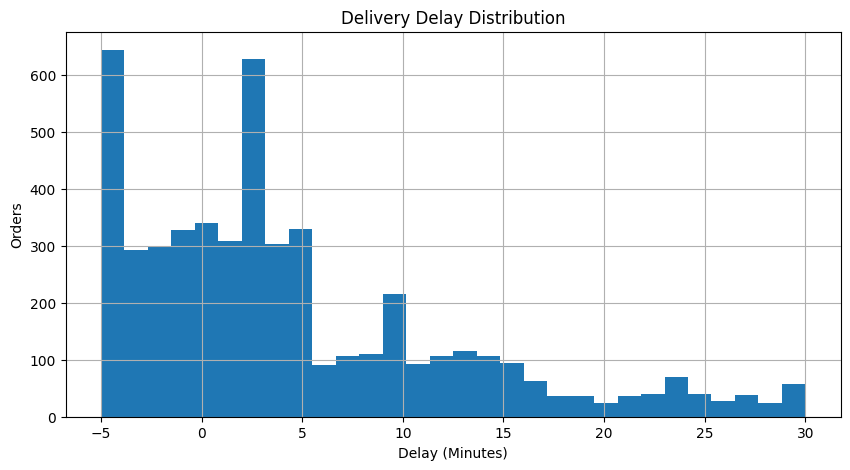

In [22]:
plt.figure(figsize=(10,5))

orders['delay_minutes'].hist(
    bins=30
)

plt.title(
    'Delivery Delay Distribution'
)

plt.xlabel(
    'Delay (Minutes)'
)

plt.ylabel(
    'Orders'
)

plt.show()

In [23]:
orders['order_date'] = pd.to_datetime(
    orders['order_date']
)

monthly_revenue = (
    orders
    .groupby(
        orders['order_date'].dt.to_period('M')
    )['order_total']
    .sum()
)

monthly_revenue

,order_total
order_date,
2023-03,272878.96
2023-04,554344.77
2023-05,608213.54
2023-06,505227.66
2023-07,567639.91
2023-08,623472.35
2023-09,571117.81
2023-10,578369.83
2023-11,567783.74


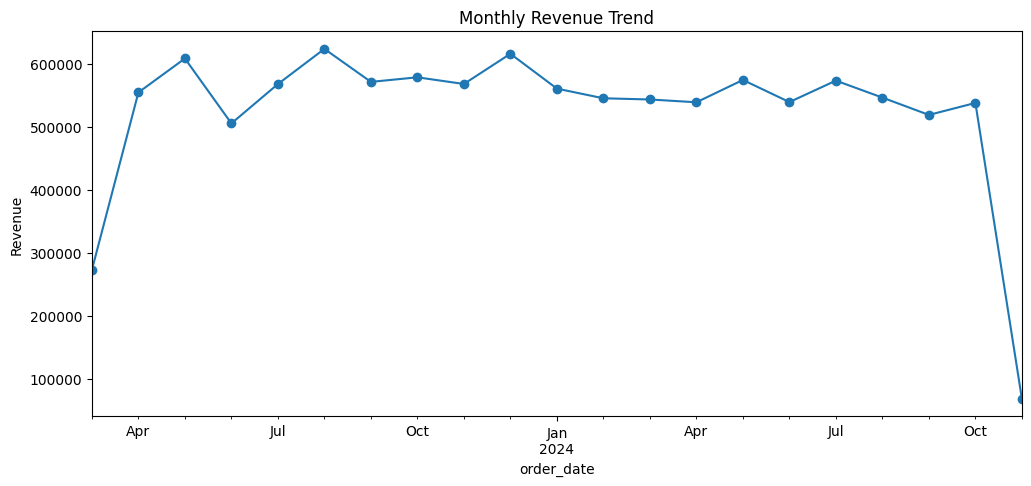

In [24]:
monthly_revenue.plot(
    figsize=(12,5),
    marker='o'
)

plt.title(
    'Monthly Revenue Trend'
)

plt.ylabel('Revenue')

plt.show()

In [25]:
inventory = pd.read_csv('blinkit_inventory.csv')

print(inventory.shape)
inventory.head()

(75172, 4)


,product_id,date,stock_received,damaged_stock
0,153019,17-03-2023,4,2
1,848226,17-03-2023,4,2
2,965755,17-03-2023,1,0
3,39154,17-03-2023,4,0
4,34186,17-03-2023,3,2


In [26]:
inventory['date'] = pd.to_datetime(
    inventory['date'],
    format='%d-%m-%Y'
)

print(
    "Total Stock Received:",
    inventory['stock_received'].sum()
)

print(
    "Total Damaged Stock:",
    inventory['damaged_stock'].sum()
)

Total Stock Received: 147526
Total Damaged Stock: 80268


In [27]:
damage_rate = (
    inventory['damaged_stock'].sum()
    /
    inventory['stock_received'].sum()
) * 100

print(
    f"Damage Rate: {damage_rate:.2f}%"
)

Damage Rate: 54.41%


In [28]:
inventory['stock_received'].describe()

,stock_received
count,75172.000000
mean,1.962513
std,1.639961
min,0.000000
25%,0.000000
50%,3.000000
75%,3.000000
max,4.000000


In [29]:
inventory['damaged_stock'].describe()

,damaged_stock
count,75172.000000
mean,1.067791
std,0.997706
min,0.000000
25%,0.000000
50%,2.000000
75%,2.000000
max,2.000000


In [30]:
inventory_product = inventory.merge(
    products,
    on='product_id',
    how='left'
)

damaged_category = (
    inventory_product
    .groupby('category')
    .agg({
        'stock_received':'sum',
        'damaged_stock':'sum'
    })
)

damaged_category['damage_rate'] = (
    damaged_category['damaged_stock']
    /
    damaged_category['stock_received']
) * 100

damaged_category.sort_values(
    'damage_rate',
    ascending=False
)

,stock_received,damaged_stock,damage_rate
category,,,
Household Care,12034,8210,68.223367
Personal Care,12239,7524,61.475611
Dairy & Breakfast,14873,8890,59.772743
Cold Drinks & Juices,11107,6604,59.457999
Fruits & Vegetables,13670,8120,59.400146
Snacks & Munchies,13845,8144,58.822680
Instant & Frozen Food,10183,5910,58.037906
Baby Care,9700,4828,49.773196
Grocery & Staples,15036,7144,47.512636


In [31]:
marketing = pd.read_csv(
    'blinkit_marketing_performance.csv'
)

print(marketing.shape)

marketing.head()

(5400, 11)


,campaign_id,campaign_name,date,target_audience,channel,impressions,clicks,conversions,spend,revenue_generated,roas
0,548299,New User Discount,2024-11-05,Premium,App,3130,163,78,1431.85,4777.75,3.60
1,390914,Weekend Special,2024-11-05,Inactive,App,3925,494,45,4506.34,6238.11,2.98
2,834385,Festival Offer,2024-11-05,Inactive,Email,7012,370,78,4524.23,2621.00,2.95
3,241523,Flash Sale,2024-11-05,Inactive,SMS,1115,579,86,3622.79,2955.00,2.84
4,595111,Membership Drive,2024-11-05,New Users,Email,7172,795,54,2888.99,8951.81,2.22


In [32]:
feedback = pd.read_csv(
    'blinkit_customer_feedback.csv'
)

print(feedback.shape)

feedback.head()

(5000, 8)


,feedback_id,order_id,customer_id,rating,feedback_text,feedback_category,sentiment,feedback_date
0,2234710,1961864118,30065862,4,"It was okay, nothing special.",Delivery,Neutral,2024-07-17
1,5450964,1549769649,9573071,3,The order was incorrect.,App Experience,Negative,2024-05-28
2,482108,9185164487,45477575,3,"It was okay, nothing special.",App Experience,Neutral,2024-09-23
3,4823104,9644738826,88067569,4,The product met my expectations.,App Experience,Neutral,2023-11-24
4,3537464,5427684290,83298567,3,Product was damaged during delivery.,Delivery,Negative,2023-11-20


In [33]:
print("Total Spend:", marketing['spend'].sum())
print("Total Revenue:", marketing['revenue_generated'].sum())
print("Average ROAS:", round(marketing['roas'].mean(),2))

Total Spend: 16319838.24
Total Revenue: 32193407.37
Average ROAS: 2.74


In [34]:
channel_performance = marketing.groupby('channel').agg({
    'revenue_generated':'sum',
    'spend':'sum',
    'conversions':'sum'
})

channel_performance['ROAS'] = (
    channel_performance['revenue_generated']
    /
    channel_performance['spend']
)

channel_performance.sort_values(
    'ROAS',
    ascending=False
)

,revenue_generated,spend,conversions,ROAS
channel,,,,
Email,8189331.58,3997488.04,74671,2.048619
SMS,7938649.32,3998607.54,73235,1.985353
Social Media,7990415.98,4110363.91,74940,1.943968
App,8075010.49,4213378.75,75192,1.916517


In [35]:
feedback['rating'].value_counts().sort_index()

,count
rating,
1,540
2,538
3,1398
4,1708
5,816


In [36]:
print(
    "Average Rating:",
    round(
        feedback['rating'].mean(),
        2
    )
)

Average Rating: 3.34


In [37]:
feedback['sentiment'].value_counts()

,count
sentiment,
Neutral,1738
Negative,1642
Positive,1620


In [38]:
feedback['feedback_category'].value_counts()

,count
feedback_category,
Delivery,1271
Customer Service,1266
Product Quality,1250
App Experience,1213
